### Cluster Analysis OF Automotive Industry Leaders

### Research Questions - 
“What distinct sustainability profiles can be identified among leading automotive companies based on their environmental, social and governance performance?” and 
“How do the identified sustainability profiles differ in terms of company size?”

## 1st Research Question - What distinct sustainability profiles can be identified among leading automotive companies based on their environmental, social and governance performance?

In [26]:
# Numerical and data manipulation libraries
import numpy as np
import pandas as pd

# Data visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Standardisation
from sklearn.preprocessing import StandardScaler

# K-Means clustering and clustering evaluation
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Hierarchical clustering
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

In [27]:
df = pd.read_excel('Dataset_Automotive.xlsx')
df.head()

,Unnamed: 0,Company name Latin alphabet,Inactive,Quoted,Branch,OwnData,Woco,Country ISO code,"NACE Rev. 2, core code (4 digits)",Consolidation code,Last avail. year,Operating revenue (Turnover) th USD Last avail. yr,Number of employees Last avail. yr,ESG Score,Environmental Score,Social Score,Governance Score
0,1.0,FORD MOTOR COMPANY,No,Yes,No,No,Yes,US,2910,C1,2025,1.872670e+08,169000,73,81,83,44
1,2.0,GENERAL MOTORS COMPANY,No,Yes,No,No,Yes,US,2910,C1,2025,1.850190e+08,156000,65,70,64,59
2,3.0,STELLANTIS N.V.,No,Yes,No,No,No,NL,2910,C1,2025,1.803719e+08,258668,85,97,85,68
3,4.0,BAYERISCHE MOTOREN WERKE AG,No,Yes,No,No,Yes,DE,2910,C2,2025,1.577014e+08,154540,88,94,90,76
4,5.0,MERCEDES-BENZ GROUP AG,No,Yes,No,No,Yes,DE,2910,C2,2025,1.570751e+08,164120,83,95,78,76


In [28]:
#Inspect datatypes and missing values using '.info()'
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 17 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Unnamed: 0                                          13 non-null     float64
 1   Company name Latin alphabet                         13 non-null     str    
 2   Inactive                                            13 non-null     str    
 3   Quoted                                              13 non-null     str    
 4   Branch                                              13 non-null     str    
 5   OwnData                                             13 non-null     str    
 6   Woco                                                13 non-null     str    
 7   Country ISO code                                    13 non-null     str    
 8   NACE Rev. 2, core code (4 digits)                   13 non-null     int64  
 9   Consolidatio

In [29]:
# Revision: Descriptive Statistics

df.describe()

,Unnamed: 0,"NACE Rev. 2, core code (4 digits)",Last avail. year,Operating revenue (Turnover) th USD Last avail. yr,ESG Score,Environmental Score,Social Score,Governance Score
count,13.00000,13.0,13.000000,1.300000e+01,13.000000,13.000000,13.000000,13.000000
mean,7.00000,2910.0,2024.923077,1.285425e+08,76.923077,85.538462,80.615385,58.461538
std,3.89444,0.0,0.493548,4.469902e+07,7.111745,8.140592,8.401770,16.338173
min,1.00000,2910.0,2024.000000,5.690364e+07,65.000000,70.000000,64.000000,33.000000
25%,4.00000,2910.0,2025.000000,9.482700e+07,72.000000,79.000000,75.000000,44.000000
50%,7.00000,2910.0,2025.000000,1.298031e+08,77.000000,86.000000,82.000000,64.000000
75%,10.00000,2910.0,2025.000000,1.577014e+08,83.000000,94.000000,85.000000,68.000000
max,13.00000,2910.0,2026.000000,1.872670e+08,88.000000,97.000000,93.000000,80.000000


# Checking Missing Values 

In [30]:
# Checking any missing values by printing them
print(df.isnull().sum())

Unnamed: 0                                            0
Company name Latin alphabet                           0
Inactive                                              0
Quoted                                                0
Branch                                                0
OwnData                                               0
Woco                                                  0
Country ISO code                                      0
NACE Rev. 2, core code (4 digits)                     0
Consolidation code                                    0
Last avail. year                                      0
Operating revenue (Turnover) th USD Last avail. yr    0
Number of employees Last avail. yr                    0
ESG Score                                             0
Environmental Score                                   0
Social Score                                          0
Governance Score                                      0
dtype: int64


# Checking Duplicates

In [31]:
#Check for the number of duplicated values using '.duplicated().sum()'
dup_count = df.duplicated().sum()
print("\nNumber of duplicate rows:", dup_count)



Number of duplicate rows: 0


In [32]:
#Check the columns included using '.columns'
df.columns

Index(['Unnamed: 0', 'Company name Latin alphabet', 'Inactive', 'Quoted',
       'Branch', 'OwnData', 'Woco', 'Country ISO code',
       'NACE Rev. 2, core code (4 digits)', 'Consolidation code',
       'Last avail. year',
       'Operating revenue (Turnover) th USD Last avail. yr',
       'Number of employees Last avail. yr', 'ESG Score ',
       'Environmental Score ', 'Social Score ', 'Governance Score'],
      dtype='str')

# Checking Outliars 

In [33]:
# Calculate the first quartile (Q1) and third quartile (Q3) of operating revenue
q1 = df["Operating revenue (Turnover) th USD Last avail. yr"].quantile(0.25)
q3 = df["Operating revenue (Turnover) th USD Last avail. yr"].quantile(0.75)

# Calculate the Interquartile Range (IQR)
iqr = q3 - q1
# Define the lower and upper boundaries for identifying outliers
lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr
# Identify revenue observations outside the IQR boundaries as potential outliers
df["Operating revenue (Turnover) th USD Last avail. yr_is_outlier"] = (df["Operating revenue (Turnover) th USD Last avail. yr"] < lower) | (df["Operating revenue (Turnover) th USD Last avail. yr"] > upper)
df["Operating revenue (Turnover) th USD Last avail. yr_is_outlier"].value_counts()

Operating revenue (Turnover) th USD Last avail. yr_is_outlier
False    13
Name: count, dtype: int64

In [34]:
# Cap extreme revenue values at the previously calculated lower and upper IQR boundaries
# to reduce the influence of potential outliers without removing any companies.
df["Operating revenue (Turnover) th USD Last avail. yr_capped"] = df["Operating revenue (Turnover) th USD Last avail. yr"].clip(lower=lower, upper=upper)
# Compare the original and capped revenue variables using descriptive statistics
# to assess the effect of the outlier treatment.
df[["Operating revenue (Turnover) th USD Last avail. yr","Operating revenue (Turnover) th USD Last avail. yr_capped"]].describe() 

,Operating revenue (Turnover) th USD Last avail. yr,Operating revenue (Turnover) th USD Last avail. yr_capped
count,1.300000e+01,1.300000e+01
mean,1.285425e+08,1.285425e+08
std,4.469902e+07,4.469902e+07
min,5.690364e+07,5.690364e+07
25%,9.482700e+07,9.482700e+07
50%,1.298031e+08,1.298031e+08
75%,1.577014e+08,1.577014e+08
max,1.872670e+08,1.872670e+08


# Feature Selection 

In [35]:
# Remove leading and trailing whitespace from all column names
# to ensure consistent column names and prevent errors when selecting variables.
df.columns = df.columns.str.strip()
# Display all column names in the dataset
# to verify that the column names are correct and free from unwanted spaces.
print(df.columns.tolist())

['Unnamed: 0', 'Company name Latin alphabet', 'Inactive', 'Quoted', 'Branch', 'OwnData', 'Woco', 'Country ISO code', 'NACE Rev. 2, core code (4 digits)', 'Consolidation code', 'Last avail. year', 'Operating revenue (Turnover) th USD Last avail. yr', 'Number of employees Last avail. yr', 'ESG Score', 'Environmental Score', 'Social Score', 'Governance Score', 'Operating revenue (Turnover) th USD Last avail. yr_is_outlier', 'Operating revenue (Turnover) th USD Last avail. yr_capped']


In [36]:
# Select the Environmental, Social, and Governance scores as the variables for clustering
X = df[['Environmental Score',
        'Social Score',
        'Governance Score']]
X.describe()

,Environmental Score,Social Score,Governance Score
count,13.000000,13.000000,13.000000
mean,85.538462,80.615385,58.461538
std,8.140592,8.401770,16.338173
min,70.000000,64.000000,33.000000
25%,79.000000,75.000000,44.000000
50%,86.000000,82.000000,64.000000
75%,94.000000,85.000000,68.000000
max,97.000000,93.000000,80.000000


## Standardisation

In [37]:
from sklearn.preprocessing import StandardScaler

# Select clustering variables
X = df[['Environmental Score', 'Social Score', 'Governance Score']]

# Standardise variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

X_scaled.describe()

,Environmental Score,Social Score,Governance Score
count,1.300000e+01,1.300000e+01,1.300000e+01
mean,6.533235e-16,2.647455e-16,1.024821e-16
std,1.040833e+00,1.040833e+00,1.040833e+00
min,-1.986704e+00,-2.058357e+00,-1.622042e+00
25%,-8.359892e-01,-6.956483e-01,-9.212809e-01
50%,5.901100e-02,1.715297e-01,3.528310e-01
75%,1.081868e+00,5.431775e-01,6.076533e-01
max,1.465440e+00,1.534238e+00,1.372120e+00


### Using the Elbow Method to Determine the Optimal Number of Clusters


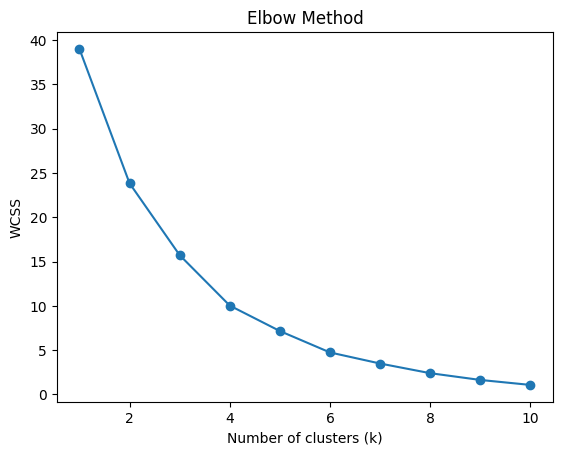

In [38]:

# Create an empty list to store the Within-Cluster Sum of Squares (WCSS) for each value of k
wcss = []
# Define the range of cluster numbers to evaluate, from 1 to 10 clusters

k_range = range(1, 11)

for k in k_range:
    model = KMeans(n_clusters=k,        # Number of clusters to run the clustering model on
                   init='k-means++',    # Initialization method for centroids
                   random_state=42,     # Fixed random state for reproducibility
                   n_init=20)           # Run the algorithm 20 times with different initializations and keep the best
    model.fit(X_scaled)                        # Fit KMeans to the data
    wcss.append(model.inertia_)      # Store the WCSS (inertia) value for the current model

# Plot the elbow graph to help choose the optimal number of clusters
plt.plot(k_range, wcss, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()# List to store the Within-Cluster Sum of Squares (WCSS) for each value of k


In [39]:
# Run K-Means for the selected number of clusters

kmeans = KMeans(n_clusters=4, init='k-means++',random_state=42, n_init=20)
df["cluster_kmeans"] = kmeans.fit_predict(X_scaled)

In [40]:
df["cluster_kmeans"]

0     2
1     1
2     0
3     0
4     0
5     3
6     2
7     3
8     2
9     1
10    3
11    2
12    0
Name: cluster_kmeans, dtype: int32

### Silhouette score

In [41]:
# Silhouette score
sil = silhouette_score(X_scaled, df["cluster_kmeans"])
print(f"Silhouette score (k=4): {sil:.8f}")


Silhouette score (k=4): 0.32955309


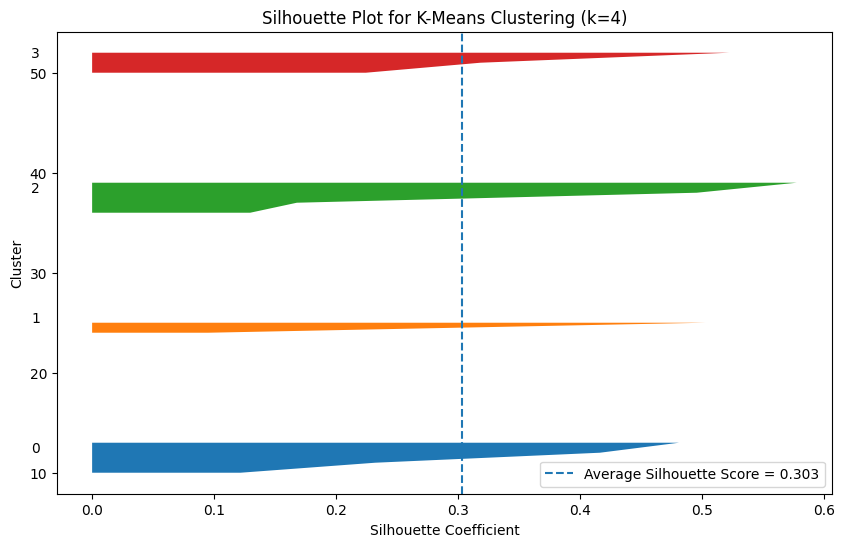

In [71]:
from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt
import numpy as np

# Calculate silhouette score for each observation
sample_silhouette_values = silhouette_samples(
    X_scaled,
    df["cluster_kmeans"]
)

# Plot
plt.figure(figsize=(10, 6))

y_lower = 10

for i in range(4):  # k = 4
    cluster_values = sample_silhouette_values[df["cluster_kmeans"] == i]
    cluster_values.sort()

    size_cluster = len(cluster_values)
    y_upper = y_lower + size_cluster

    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_values
    )

    plt.text(-0.05, (y_lower + y_upper) / 2, str(i))

    y_lower = y_upper + 10

# Average silhouette score
plt.axvline(
    x=sil,
    linestyle="--",
    label=f"Average Silhouette Score = {sil:.3f}"
)

plt.xlabel("Silhouette Coefficient")
plt.ylabel("Cluster")
plt.title("Silhouette Plot for K-Means Clustering (k=4)")
plt.legend()
plt.show()

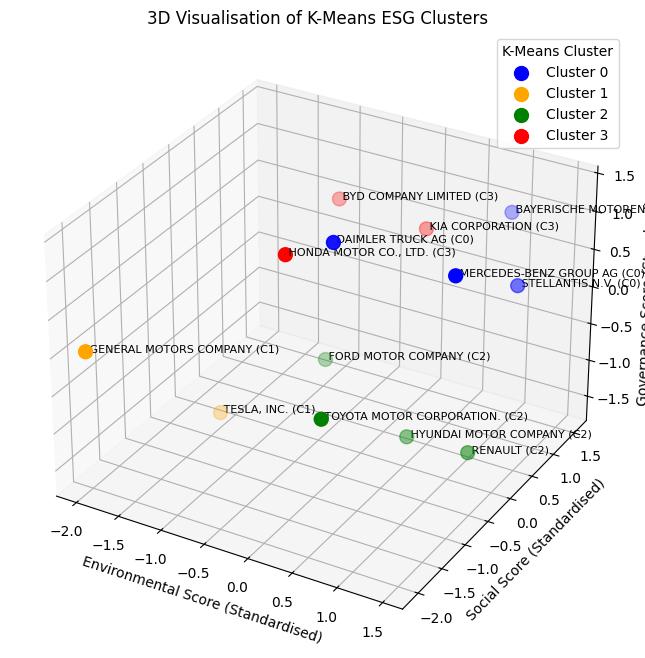

In [69]:
# Create a 3D figure to visualise the K-Means clusters using the three ESG variables
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
# Define a separate colour for each K-Means cluster
cluster_colors = {
    0: 'blue',
    1: 'orange',
    2: 'green',
    3: 'red'
}
# Plot each K-Means cluster separately
for cluster in [0, 1, 2,3]:
 # Select the companies belonging to the current cluster
    cluster_data = df[df["cluster_kmeans"] == cluster]
    # Plot the standardised Environmental, Social, and Governance scores
    # on the X, Y, and Z axes respectively
    ax.scatter(
        X_scaled.loc[cluster_data.index, "Environmental Score"],
        X_scaled.loc[cluster_data.index, "Social Score"],
        X_scaled.loc[cluster_data.index, "Governance Score"],
        color=cluster_colors[cluster],
        s=100,
        label=f"Cluster {cluster}"
    )

# Company labels
for i in range(len(df)):

    cluster = df["cluster_kmeans"].iloc[i]

    ax.text(
        X_scaled["Environmental Score"].iloc[i],
        X_scaled["Social Score"].iloc[i],
        X_scaled["Governance Score"].iloc[i],
        f" {df['Company name Latin alphabet'].iloc[i]} (C{cluster})",
        fontsize=8
    )

ax.set_xlabel("Environmental Score (Standardised)")
ax.set_ylabel("Social Score (Standardised)")
ax.set_zlabel("Governance Score (Standardised)")

ax.set_title("3D Visualisation of K-Means ESG Clusters")

ax.legend(title="K-Means Cluster")

plt.show()

## Centroid Values 

In [43]:
# Extract the K-Means cluster centroids for the three ESG variables
# to identify the average standardised ESG position of each cluster.
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=[
        "Environmental Score",
        "Social Score",
        "Governance Score"
    ]
)
# Label the rows according to their corresponding K-Means cluster

centroids.index.name = "Cluster"

centroids

,Environmental Score,Social Score,Governance Score
Cluster,,,
0,0.954011,0.171530,1.053592
1,-1.475275,-1.624768,-0.443489
2,0.250797,-0.045265,-1.223882
3,-0.622894,0.914825,0.522713


In [44]:
centroids.round(2)

,Environmental Score,Social Score,Governance Score
Cluster,,,
0,0.95,0.17,1.05
1,-1.48,-1.62,-0.44
2,0.25,-0.05,-1.22
3,-0.62,0.91,0.52


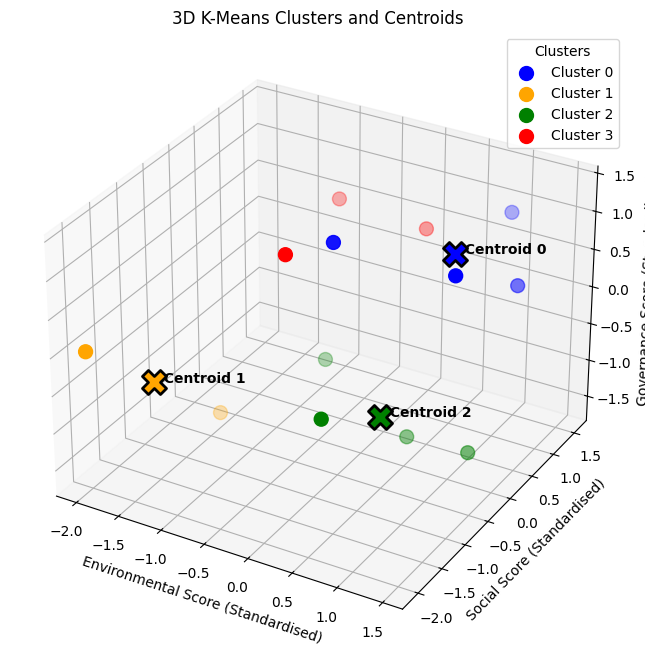

In [70]:
# Create a 3D figure for visualising the K-Means clusters
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
# Assign a unique colour to each K-Means cluster
# to make the clusters easier to distinguish in the visualisation
cluster_colors = {
    0: 'blue',
    1: 'orange',
    2: 'green',
    3: 'red'
}

# Plot companies
for cluster in [0, 1, 2,3]:

    cluster_data = df[df["cluster_kmeans"] == cluster]

    ax.scatter(
        X_scaled.loc[cluster_data.index, "Environmental Score"],
        X_scaled.loc[cluster_data.index, "Social Score"],
        X_scaled.loc[cluster_data.index, "Governance Score"],
        color=cluster_colors[cluster],
        s=100,
        label=f"Cluster {cluster}"
    )

# Plot centroids
for cluster in [0, 1, 2]:

    ax.scatter(
        centroids.loc[cluster, "Environmental Score"],
        centroids.loc[cluster, "Social Score"],
        centroids.loc[cluster, "Governance Score"],
        color=cluster_colors[cluster],
        marker='X',
        s=300,
        edgecolor='black',
        linewidth=2
    )

    # Label centroid
    ax.text(
        centroids.loc[cluster, "Environmental Score"],
        centroids.loc[cluster, "Social Score"],
        centroids.loc[cluster, "Governance Score"],
        f"  Centroid {cluster}",
        fontsize=10,
        fontweight='bold'
    )

ax.set_xlabel("Environmental Score (Standardised)")
ax.set_ylabel("Social Score (Standardised)")
ax.set_zlabel("Governance Score (Standardised)")

ax.set_title("3D K-Means Clusters and Centroids")

ax.legend(title="Clusters")

plt.show()

In [65]:
#  Interpretation of the clusters 

df.groupby("cluster_kmeans")[["Environmental Score", "Social Score", 'Governance Score']].mean()

,Environmental Score,Social Score,Governance Score
cluster_kmeans,,,
0,93.000000,82.00,75.000000
1,74.000000,67.50,51.500000
2,87.500000,80.25,39.250000
3,80.666667,88.00,66.666667


In [67]:
df[[
    "Company name Latin alphabet",
    "Environmental Score",
    "Social Score",
    "Governance Score",
    "cluster_kmeans"
]].sort_values("cluster_kmeans")

,Company name Latin alphabet,Environmental Score,Social Score,Governance Score,cluster_kmeans
3,BAYERISCHE MOTOREN WERKE AG,94,90,76,0
2,STELLANTIS N.V.,97,85,68,0
4,MERCEDES-BENZ GROUP AG,95,78,76,0
12,DAIMLER TRUCK AG,86,75,80,0
9,"TESLA, INC.",78,71,44,1
1,GENERAL MOTORS COMPANY,70,64,59,1
0,FORD MOTOR COMPANY,81,83,44,2
6,HYUNDAI MOTOR COMPANY,89,82,34,2
11,RENAULT,94,83,33,2
8,TOYOTA MOTOR CORPORATION.,86,73,46,2


## Interpretation

 Cluster 0 — Strong and Balanced Sustainability Leaders - Cluster 0 represents a “Strong and Balanced Sustainability Leaders” profile. Companies within this cluster demonstrate consistently strong performance across all three ESG dimensions. The cluster records the highest Environmental score (93.00) and the highest Governance score (75.00), while its Social score of 82.00 is also above the overall sample level. Its overall ESG score of 84.00 further indicates strong aggregate sustainability performance. Therefore, Cluster 0 represents the most comprehensive sustainability profile identified among the automotive companies.

Cluster 1 — Lower Sustainability Performance - Cluster 1 represents a “Lower Sustainability Performance” profile. Companies in this cluster record below-average performance across Environmental, Social and Governance dimensions. Environmental performance is particularly weak, with an average score of 74.00, while Social performance is also relatively low at 67.50. Governance performance is comparatively higher than the other two dimensions within the cluster but remains below the broader sample level. The overall ESG score of 66.00 is the lowest of the four clusters. Therefore, this cluster represents the least developed overall sustainability profile identified in the sample.

Cluster 2 — Environmental and Social Strength with Governance Weakness - Cluster 2 represents an “Environmental and Social Strength with Governance Weakness” profile. Companies within this cluster demonstrate relatively strong Environmental performance, with an average score of 87.50, and relatively strong Social performance at 80.25. However, Governance performance is substantially weaker, with an average score of only 39.25. The Governance score is considerably below the scores observed for the other two ESG dimensions within the cluster. This indicates that strong Environmental and Social performance does not necessarily correspond with equally strong Governance performance.

Cluster 3 — Socially Strong Sustainability Performers - Cluster 3 represents a “Socially Strong Sustainability Performers” profile. The defining characteristic of this cluster is its particularly high Social performance, with an average score of 88.00, the highest among the four clusters. Governance performance is also relatively strong at 66.67, whereas Environmental performance is comparatively lower at 80.67. The results therefore suggest that companies in this group place relatively greater emphasis on the Social dimension of sustainability while maintaining reasonably strong Governance performance.


## Conclusion 
The cluster analysis identifies four distinct sustainability profiles among the automotive companies. Cluster 0 represents the strongest and most balanced sustainability profile, characterised by high Environmental, Social and Governance performance. Cluster 1 represents a comparatively lower sustainability profile, with below-average performance across all three dimensions. Cluster 2 demonstrates strong Environmental and Social performance but substantially weaker Governance performance, highlighting an imbalance in sustainability capabilities. Cluster 3 is characterised by particularly strong Social performance alongside relatively strong Governance performance. Overall, the results demonstrate that sustainability performance among automotive industry leaders is heterogeneous, with companies exhibiting different combinations of ESG strengths and weaknesses rather than following a single sustainability pattern.

# Hirarchical Clustering 

The hierarchical clustering results broadly corroborate the profiles identified through K-Means. Although the numerical cluster labels differ between the two methods, the underlying cluster characteristics are highly similar. The hierarchical approach identifies a strong and balanced group, a lower-performing group, a group with relatively strong Environmental and Social performance but weak Governance, and a socially strong group. This consistency suggests that the identified sustainability profiles are not solely dependent on the K-Means algorithm.

### Dendogram 

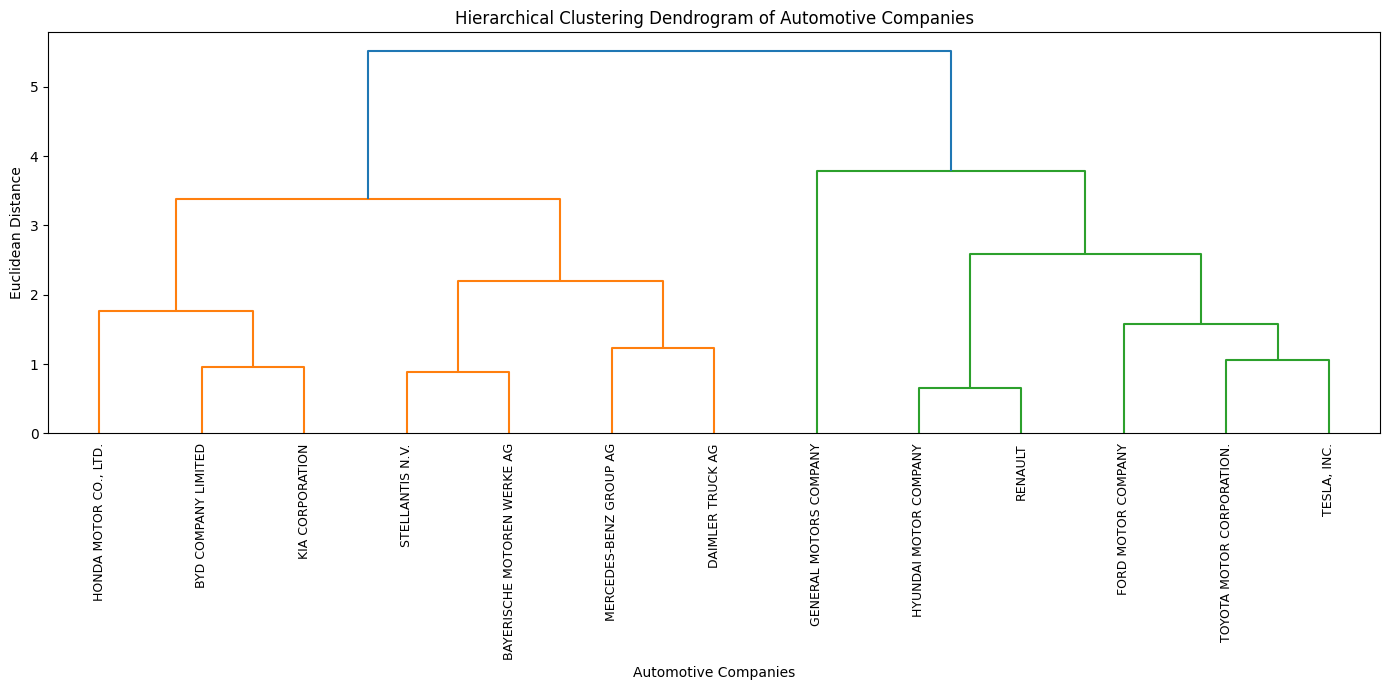

In [47]:
## Dendogram Visulaistion

# Generate the linkage matrix using Ward's method
# X_scaled contains the standardised ESG variables

linkage_matrix = sch.linkage(X_scaled, method='ward')

# Create the dendrogram
plt.figure(figsize=(14, 7))

sch.dendrogram(
    linkage_matrix,
    labels=df['Company name Latin alphabet'].values,
    leaf_rotation=90,
    leaf_font_size=9
)

# Title
plt.title('Hierarchical Clustering Dendrogram of Automotive Companies')

# X-axis
plt.xlabel('Automotive Companies')

# Y-axis
plt.ylabel('Euclidean Distance')

# Display the dendrogram
plt.tight_layout()
plt.show()

## Dendogram Interpretation 
The Ward hierarchical dendrogram illustrates the degree of similarity between the automotive companies based on their standardised Environmental, Social and Governance scores. Companies or groups joined at relatively low distances exhibit greater similarity in their sustainability profiles, whereas branches merged at higher distances indicate greater dissimilarity. The formation of several distinct branches before the final mergers indicates that the automotive companies do not form one homogeneous sustainability group. This visual evidence is consistent with the four sustainability profiles identified through K-Means.

In [48]:
# Initialize Agglomerative Hierarchical Clustering
# - n_clusters=4: Target number of clusters
# - linkage='ward': Use Ward's method to minimize variance within clusters
hc = AgglomerativeClustering(n_clusters=4, linkage='ward')

# Fit the model to the data and predict cluster labels for each observation
y_hc = hc.fit_predict(X_scaled)
df["cluster_hc"] = y_hc # Store the clusters in the dataset

In [49]:
# Silhouette score for hierarchical clustering
sil = silhouette_score(X_scaled, y_hc)
print(f"Silhouette score (k=4): {sil:.4f}")

Silhouette score (k=4): 0.2830


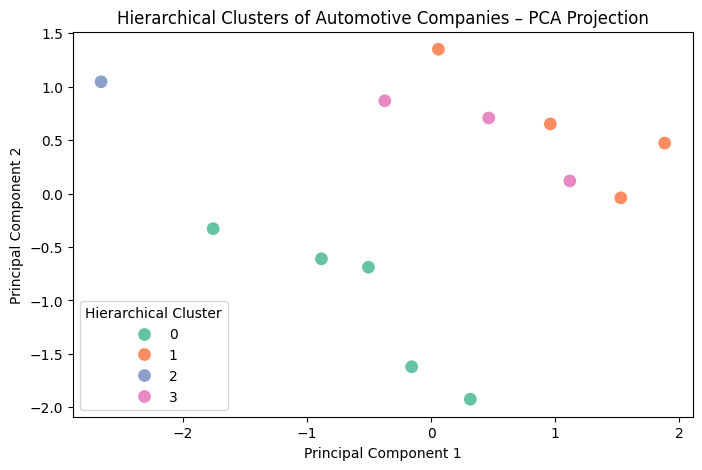

In [72]:
## Visualisation of Hierarchical Clustering 

# PCA: reduce 3 ESG variables to 2 dimensions
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Create PCA dataframe
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=df.index
)

# Add hierarchical cluster
pca_df["cluster_hc"] = df["cluster_hc"]

# Plot
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster_hc",
    palette="Set2",
    s=100
)

plt.title("Hierarchical Clusters of Automotive Companies – PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Hierarchical Cluster")

plt.show()

In [51]:
# Calculate the PCA loadings to show the contribution of each ESG variable
# to the first two principal components.
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=[
        "Environmental Score",
        "Social Score",
        "Governance Score"
    ]
)
# Round the loading values to three decimal places
# for easier interpretation and presentation.
loadings.round(3)

,PC1,PC2
Environmental Score,0.645,-0.354
Social Score,0.675,-0.151
Governance Score,0.358,0.923


## PCA Interpretation 
The PCA projection provides additional visual evidence of the structure identified through hierarchical clustering. PC1 is primarily associated with Environmental and Social performance, while PC2 is strongly associated with Governance performance. This indicates that differences in Environmental/Social performance and Governance performance constitute important sources of variation between the automotive companies. In particular, companies characterised by stronger Environmental and Social performance but substantially weaker Governance performance form a distinguishable profile, supporting the identification of the governance-weak cluster.

In [52]:
# interpretation of the clusters

df.groupby("cluster_hc")[["Environmental Score", "Social Score", 'Governance Score']].mean()

,Environmental Score,Social Score,Governance Score
cluster_hc,,,
0,85.600000,78.4,40.200000
1,93.000000,82.0,75.000000
2,70.000000,64.0,59.000000
3,80.666667,88.0,66.666667


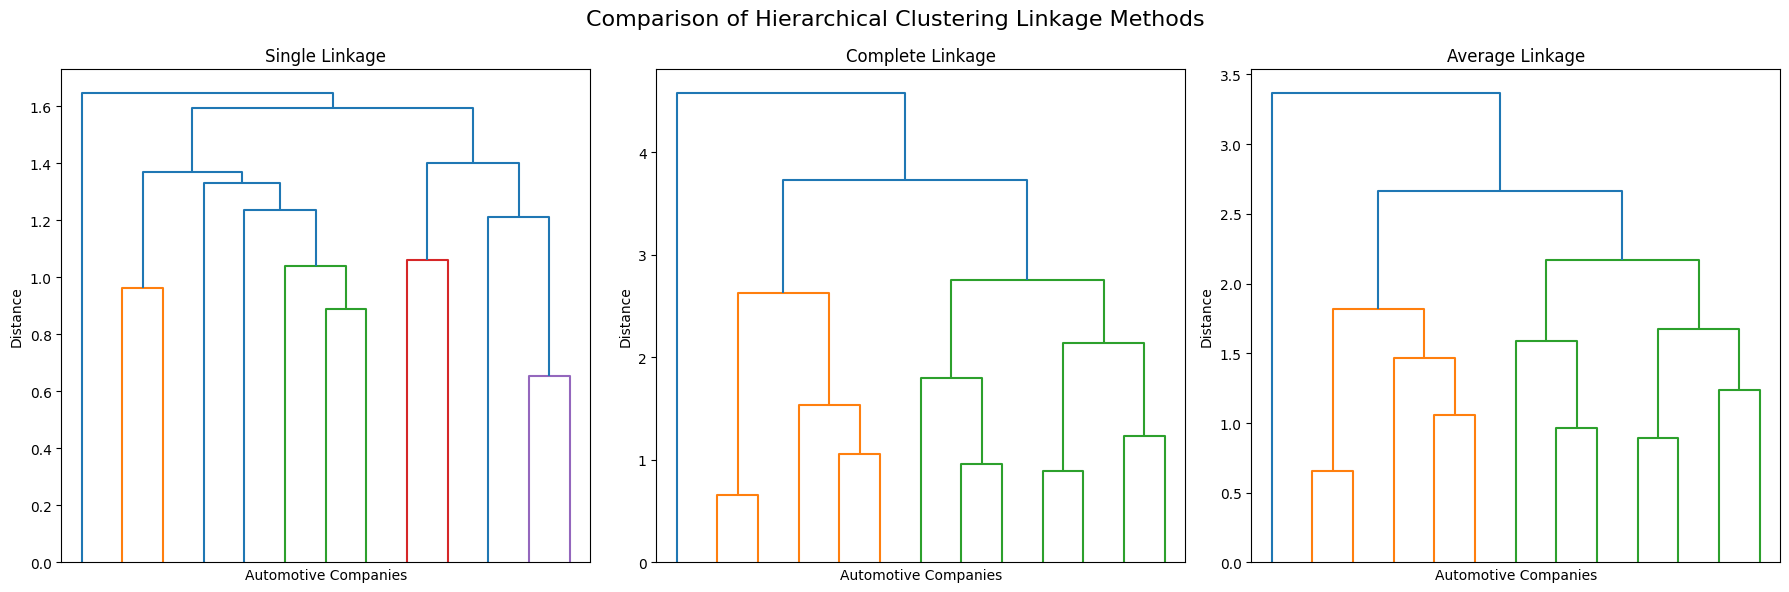

In [53]:
# Linkage methods to compare
methods = ["single", "complete", "average"]

plt.figure(figsize=(18, 6))

for i, method in enumerate(methods, 1):

    plt.subplot(1, 3, i)

    # Generate linkage matrix using the standardised ESG variables
    linkage_matrix = sch.linkage(
        X_scaled,
        method=method
    )

    # Create dendrogram
    sch.dendrogram(
        linkage_matrix,
        no_labels=True
    )

    plt.title(f"{method.capitalize()} Linkage")
    plt.xlabel("Automotive Companies")
    plt.ylabel("Distance")

plt.suptitle(
    "Comparison of Hierarchical Clustering Linkage Methods",
    fontsize=16
)

plt.tight_layout()
plt.show()

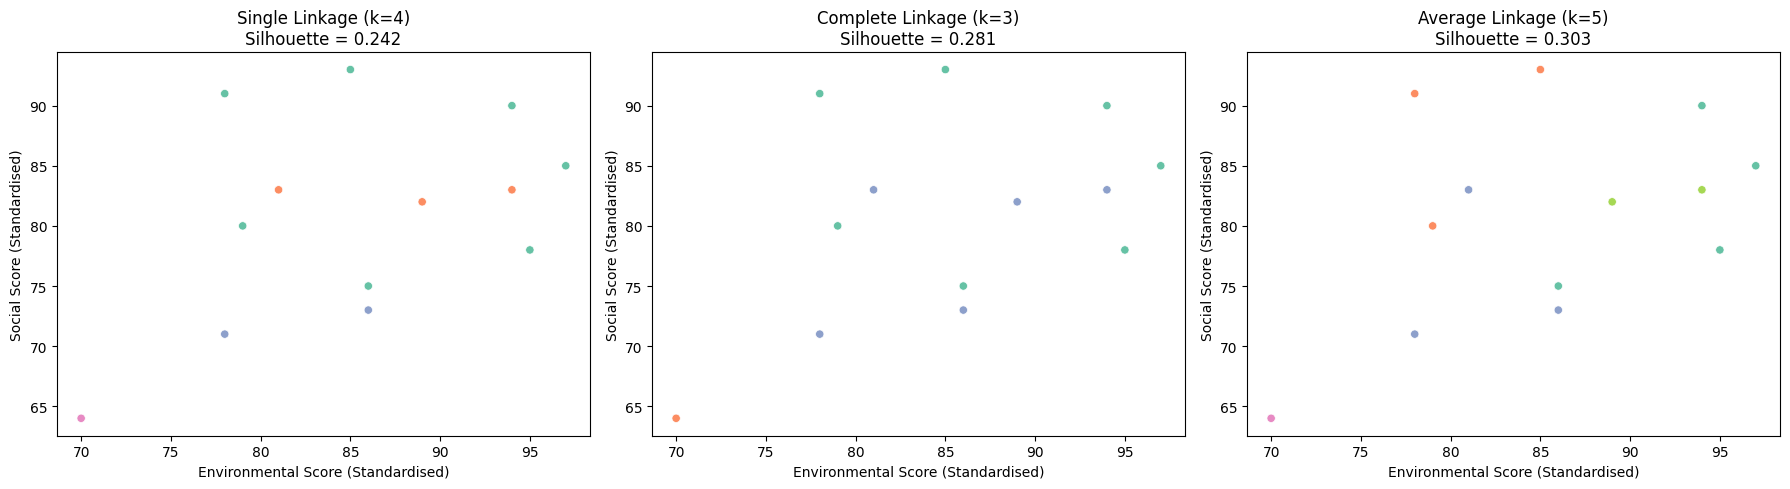

In [54]:
# Select the number of clusters for each method
# and run hierarchical clustering for each method

size = [4, 3, 5]

methods = ["single", "complete", "average"]

plt.figure(figsize=(18, 5))

for i, (method, k) in enumerate(zip(methods, size), 1):

    # Fit hierarchical clustering
    hc = AgglomerativeClustering(
        n_clusters=k,
        linkage=method
    )

    labels = hc.fit_predict(X_scaled)

    # Store cluster labels
    df[f"cluster_{method}_{k}"] = labels

    # Compute silhouette score
    sil = silhouette_score(X_scaled, labels)

    # Plot
    plt.subplot(1, 3, i)

    sns.scatterplot(
        data=df,
        x="Environmental Score",
        y="Social Score",
        hue=f"cluster_{method}_{k}",
        palette="Set2",
        legend=False
    )

    plt.title(
        f"{method.capitalize()} Linkage (k={k})\n"
        f"Silhouette = {sil:.3f}"
    )

    plt.xlabel("Environmental Score (Standardised)")
    plt.ylabel("Social Score (Standardised)")

plt.tight_layout()
plt.show()

## Comparison of Hirarchical Linkage method 
Single Linkage Dendogram - The single-linkage dendrogram illustrates the hierarchical structure formed by considering the minimum distance between observations in different clusters. The resulting structure provides evidence of similarity between companies with comparable ESG profiles; however, single linkage can produce elongated or chained clusters when observations are connected through intermediate companies. Therefore, the single-linkage solution provides useful information about local similarities between automotive companies but may provide less clearly separated sustainability groups than alternative linkage methods.

Complete-linkage dendrogram - The complete-linkage dendrogram produces a more compact clustering structure by considering the maximum distance between observations when merging groups. In comparison with single linkage, the resulting three-cluster structure indicates that some of the distinctions observed under other linkage approaches are combined when greater within-cluster compactness is required. This suggests that certain automotive companies have sufficiently similar ESG profiles to be grouped together under a stricter cluster-separation criterion.

Average-linkage dendrogram - 
The average-linkage dendrogram produces a five-cluster structure, providing a somewhat more differentiated representation of the sustainability profiles than the complete-linkage solution. This suggests that some companies that are grouped together under complete linkage can be distinguished when average distances between observations are considered. The result highlights the sensitivity of hierarchical clustering to the choice of linkage criterion.


## The Key Finding 
The comparison of linkage methods demonstrates that the hierarchical clustering structure is sensitive to the definition of inter-cluster distance. Single linkage produced four clusters, complete linkage produced three clusters, and average linkage produced five clusters. This variation indicates that the number and composition of hierarchical clusters can change depending on the linkage criterion applied. Consequently, the linkage comparison is used as a sensitivity analysis rather than as evidence that one method provides an objectively correct number of sustainability profiles.


### Second Research Question - “How do the identified sustainability profiles differ in terms of company size?”

In [55]:
# Check the data types of the Revenue and Number of Employees variables
# to ensure that they are stored in a suitable numeric format for analysis.
print(df[
    ["Operating revenue (Turnover) th USD Last avail. yr",
     "Number of employees Last avail. yr"]
].dtypes)

Operating revenue (Turnover) th USD Last avail. yr    float64
Number of employees Last avail. yr                     object
dtype: object


In [56]:
# Define the Revenue and Number of Employees columns for easier reference
revenue_col = "Operating revenue (Turnover) th USD Last avail. yr"
employees_col = "Number of employees Last avail. yr"
# Convert Revenue values to numeric format
# Non-numeric or invalid values are converted to missing values (NaN)
df[revenue_col] = pd.to_numeric(
    df[revenue_col],
    errors="coerce"
)
# Convert Number of Employees values to numeric format
# Non-numeric or invalid values are converted to missing values (NaN)
df[employees_col] = pd.to_numeric(
    df[employees_col],
    errors="coerce"
)

In [57]:
# Check the number of missing values in the Revenue and Number of Employees columns
# to identify any incomplete observations before further analysis.
print(df[[revenue_col, employees_col]].isna().sum())

Operating revenue (Turnover) th USD Last avail. yr    0
Number of employees Last avail. yr                    2
dtype: int64


In [73]:
# Calculate the average Revenue and Number of Employees for each K-Means cluster
# to compare the financial and organisational size of companies ac
size_profile = df.groupby("cluster_kmeans").agg(
    Companies=("Company name Latin alphabet", lambda x: ", ".join(x)),
    Revenue=("Operating revenue (Turnover) th USD Last avail. yr", "mean"),
    Employees=("Number of employees Last avail. yr", "mean")
)
# Round the results to two decimal places for clearer presentation

size_profile.round(2)

,Companies,Revenue,Employees
cluster_kmeans,,,
0,"STELLANTIS N.V., BAYERISCHE MOTOREN WERKE AG, ...",1.380130e+08,171592.25
1,"GENERAL MOTORS COMPANY, TESLA, INC.",1.399230e+08,145392.50
2,"FORD MOTOR COMPANY, HYUNDAI MOTOR COMPANY, TOY...",1.248763e+08,113685.33
3,"HONDA MOTOR CO., LTD., BYD COMPANY LIMITED, KI...",1.132165e+08,531897.50


In [59]:
## Finding missing values
print(df[[revenue_col, employees_col]].isna().sum())

Operating revenue (Turnover) th USD Last avail. yr    0
Number of employees Last avail. yr                    2
dtype: int64


In [60]:
# Identify companies with missing values in the Number of Employees variable
# to determine which observations are affected by incomplete employee data.
missing_employees = df[
    df["Number of employees Last avail. yr"].isna()
]

missing_employees[
    ["Company name Latin alphabet", 
     "Operating revenue (Turnover) th USD Last avail. yr",
     "Number of employees Last avail. yr"]
]

,Company name Latin alphabet,Operating revenue (Turnover) th USD Last avail. yr,Number of employees Last avail. yr
6,HYUNDAI MOTOR COMPANY,1.298031e+08,NaN
10,KIA CORPORATION,7.954626e+07,NaN


In [74]:
# Calculate the average ESG scores, Revenue, and Number of Employees
# for each K-Means cluster to create a comprehensive cluster profile.
profile = df.groupby("cluster_kmeans").agg(
       
    Companies=("Company name Latin alphabet", lambda x: ", ".join(x)),
    Environment=("Environmental Score", "mean"),
    Social=("Social Score", "mean"),
    Governance=("Governance Score", "mean"),
    ESG=("ESG Score", "mean"),
    Revenue=("Operating revenue (Turnover) th USD Last avail. yr", "mean"),
    Employees=("Number of employees Last avail. yr", "mean")
)

profile.round(2)

,Companies,Environment,Social,Governance,ESG,Revenue,Employees
cluster_kmeans,,,,,,,
0,"STELLANTIS N.V., BAYERISCHE MOTOREN WERKE AG, ...",93.00,82.00,75.00,84.00,1.380130e+08,171592.25
1,"GENERAL MOTORS COMPANY, TESLA, INC.",74.00,67.50,51.50,66.00,1.399230e+08,145392.50
2,"FORD MOTOR COMPANY, HYUNDAI MOTOR COMPANY, TOY...",87.50,80.25,39.25,72.75,1.248763e+08,113685.33
3,"HONDA MOTOR CO., LTD., BYD COMPANY LIMITED, KI...",80.67,88.00,66.67,80.33,1.132165e+08,531897.50


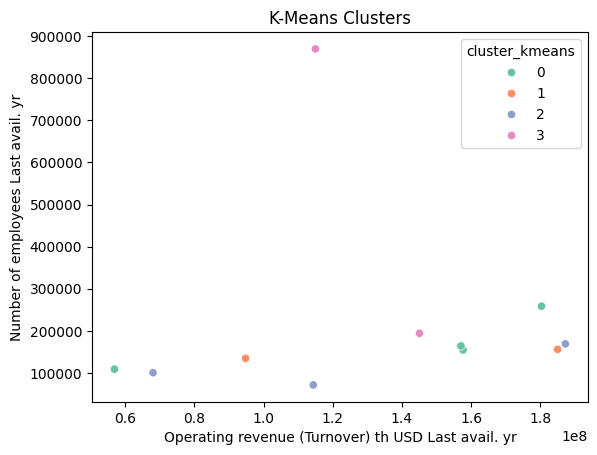

In [62]:
# Visualise the clusters

plt.figure()
sns.scatterplot(
    data=df,
    x="Operating revenue (Turnover) th USD Last avail. yr",
    y="Number of employees Last avail. yr",
    hue="cluster_kmeans",
    palette="Set2"
)

plt.title("K-Means Clusters")
plt.show()

In [75]:
# Calculate the average Revenue and Number of Employees for each K-Means cluster
# to assess differences in financial and organisational size between ESG clusters.
kmeans_profile = df.groupby("cluster_kmeans").agg(
        Companies=("Company name Latin alphabet", lambda x: ", ".join(x)),

    Revenue=(
        "Operating revenue (Turnover) th USD Last avail. yr",
        "mean"
    ),
    Employees=(
        "Number of employees Last avail. yr",
        "mean"
    )
)

kmeans_profile.round(2)

,Companies,Revenue,Employees
cluster_kmeans,,,
0,"STELLANTIS N.V., BAYERISCHE MOTOREN WERKE AG, ...",1.380130e+08,171592.25
1,"GENERAL MOTORS COMPANY, TESLA, INC.",1.399230e+08,145392.50
2,"FORD MOTOR COMPANY, HYUNDAI MOTOR COMPANY, TOY...",1.248763e+08,113685.33
3,"HONDA MOTOR CO., LTD., BYD COMPANY LIMITED, KI...",1.132165e+08,531897.50


## Interpretation
Cluster 0 - The strongest and most balanced sustainability profile is associated with relatively high company revenue and a substantial workforce. Cluster 0 records the second-highest average revenue among the four clusters and the second-highest workforce when the exceptionally large Cluster 3 is considered. This suggests that the strongest sustainability profile in the sample is associated with relatively large automotive companies, although company size alone does not appear sufficient to explain sustainability performance.

CLuster 1 - Cluster 1 has the highest average revenue of the four sustainability profiles, at approximately 139.9 million thousand USD, despite representing the lower sustainability performance group. Its average workforce of approximately 145,393 employees is also substantial. This indicates that higher revenue does not automatically correspond to stronger ESG performance within the sample. Therefore, company revenue alone does not appear to provide a sufficient explanation for differences in sustainability profiles.

Cluster 2 - Cluster 2 has a lower average revenue and workforce than Clusters 0 and 1. Its average revenue is approximately 124.9 million thousand USD, while its average workforce is approximately 113,685 employees. Despite its smaller average organisational scale relative to Clusters 0 and 1, the group demonstrates relatively strong Environmental and Social performance. This suggests that strong performance in these sustainability dimensions is not restricted to the largest companies in the sample.

Cluster 3 - Cluster 3 presents an unusual company-size profile. It records the lowest average revenue of the four clusters, at approximately 113.2 million thousand USD, but has by far the largest average workforce, at approximately 531,898 employees. This cluster is also characterised by the highest Social score. The combination suggests that the relationship between company size and sustainability performance is not straightforward: a large workforce does not necessarily correspond to the highest revenue or the strongest performance across all ESG dimensions.